In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from datasets import load_dataset
from metrics import calculate_metrics
from preprocessing import *

In [14]:
label_idx_to_name = {1: "World",  2: "Sports", 3: "Business", 4: "Sci/Tech"}

In [15]:
# Load the AG News dataset from Hugging Face
dataset = load_dataset("sh0416/ag_news")

# Convert to pandas DataFrames
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print("\nTrain data preview:")
print(train_df.head())

# Split into X (features) and y (labels)
X_train = train_df['description']
y_train = train_df['label']

X_test = test_df['description']
y_test = test_df['label']

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


Train set shape: (120000, 3)
Test set shape: (7600, 3)

Train data preview:
   label                                              title  \
0      3  Wall St. Bears Claw Back Into the Black (Reuters)   
1      3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2      3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3      3  Iraq Halts Oil Exports from Main Southern Pipe...   
4      3  Oil prices soar to all-time record, posing new...   

                                         description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  

X_train shape: (120000,)
y_train shape: (120000,)
X_test shape: (7600,)
y_test shape: (7600,)


In [16]:
X_train_preprocessed = text_normalization(X_train)
X_test_preprocessed = text_normalization(X_test)

In [17]:
# Initialize CountVectorizer for binary bigram representation
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),  # Only bigrams (2-word sequences) (lower bound=2, upper bound=2)
    binary=True,         # Binary representation (1 if present, 0 otherwise)
    token_pattern=r'\b\w+\b'  # Tokenize by word boundaries
)

# Fit on training data and transform both train and test
X_train_bigram = bigram_vectorizer.fit_transform(X_train_preprocessed)
X_test_bigram = bigram_vectorizer.transform(X_test_preprocessed)

print(f"Vocabulary size (unique bigrams): {len(bigram_vectorizer.vocabulary_)}")
print(f"X_train_bigram shape: {X_train_bigram.shape}")
print(f"X_test_bigram shape: {X_test_bigram.shape}")
print(f"Data type: {type(X_train_bigram)}")  # Sparse matrix for memory efficiency

# Show some example bigrams
print(f"\nFirst 10 bigrams in vocabulary:")
bigrams = list(bigram_vectorizer.vocabulary_.keys())[:10]
print(bigrams)

Vocabulary size (unique bigrams): 905473
X_train_bigram shape: (120000, 905473)
X_test_bigram shape: (7600, 905473)
Data type: <class 'scipy.sparse._csr.csr_matrix'>

First 10 bigrams in vocabulary:
['reuters short', 'short sellers', 'sellers wall', 'wall street', 'street s', 's dwindling', 'dwindling band', 'band of', 'of ultra', 'ultra cynics']


In [18]:
# decode the first row in X_train_bigram to see which bigrams are present
first_row_bigram = X_train_bigram[0].toarray()[0]
present_bigrams = [bigram for bigram, idx in bigram_vectorizer.vocabulary_.items() if first_row_bigram[idx] == 1]
print(f"\nBigrams present in the first training example:")
print(present_bigrams)
print(f"\nFirst training example (preprocessed): \n{X_train[0]}")


Bigrams present in the first training example:
['reuters short', 'short sellers', 'sellers wall', 'wall street', 'street s', 's dwindling', 'dwindling band', 'band of', 'of ultra', 'ultra cynics', 'cynics are', 'are seeing', 'seeing green', 'green again']

First training example (preprocessed): 
Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


In [19]:
class SoftmaxRegression:
    """
    Custom Softmax Regression implementation using NumPy with sparse matrix support.
    
    Designed for high-dimensional sparse features (e.g., text bigrams).
    Keeps data in sparse format for memory efficiency.
    """
    def __init__(self, x_train, y_train, x_val, y_val, num_classes=4):
        # Keep data in sparse format for memory efficiency
        self.x_train = x_train
        self.x_val = x_val
        
        # Convert labels to one-hot encoding
        self.y_train = self._one_hot_encode(y_train, num_classes)
        self.y_val = self._one_hot_encode(y_val, num_classes)
        
        self.N = self.x_train.shape[0]
        self.D = self.x_train.shape[1]
        self.num_classes = num_classes
        
        # He initialization (weights are always dense)
        self.weights = np.random.randn(self.D, num_classes) * np.sqrt(2.0 / self.D)
        self.train_history = None
    
    def _one_hot_encode(self, y, num_classes):
        """Convert labels to one-hot encoding"""
        if isinstance(y, pd.Series):
            y = y.values
        one_hot = np.zeros((len(y), num_classes))
        one_hot[np.arange(len(y)), y - 1] = 1  # Subtract 1 if labels are 1-indexed
        return one_hot
    
    def _softmax(self, x):
        """Compute softmax with numerical stability"""
        max_x = np.max(x, axis=1, keepdims=True)  # Prevent overflow
        exp_x = np.exp(x - max_x)
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def _forward(self, x):
        """Forward pass - sparse matrix multiplication"""
        # sparse @ dense = dense
        z = x @ self.weights
        y = self._softmax(z)
        return y
    
    def _compute_loss(self, y, y_pred):
        """Compute cross-entropy loss"""
        eps = 1e-9
        loss = -np.mean(np.sum(y * np.log(y_pred + eps), axis=1))
        return loss
    
    def _compute_acc(self, y, y_pred):
        """Compute accuracy"""
        y_labels = np.argmax(y, axis=1)
        y_pred_labels = np.argmax(y_pred, axis=1)
        return np.mean(y_labels == y_pred_labels)
    
    def _predict(self):
        """Make predictions on validation set"""
        predictions = self._forward(self.x_val)
        val_loss = self._compute_loss(self.y_val, predictions)
        val_acc = self._compute_acc(self.y_val, predictions)
        return val_loss, val_acc
    
    def _visualize_training_history(self, epochs):
        """Plot training history"""
        ep = list(range(1, epochs + 1))
        figure, axis = plt.subplots(2, 1, figsize=(10, 8))

        axis[0].plot(ep, self.train_history['train_losses'], color='blue', label='Train Loss')
        axis[0].plot(ep, self.train_history['val_losses'], color='orange', label='Val Loss')
        axis[0].set_title('Loss vs Epochs')
        axis[0].set_xlabel('Epochs')
        axis[0].set_ylabel('Loss')
        axis[0].legend()

        axis[1].plot(ep, self.train_history['train_acc'], color='blue', label='Train Acc')
        axis[1].plot(ep, self.train_history['val_acc'], color='orange', label='Val Acc')
        axis[1].set_title('Accuracy vs Epochs')
        axis[1].set_xlabel('Epochs')
        axis[1].set_ylabel('Accuracy')
        axis[1].legend()

        plt.tight_layout()
        plt.show()
        
    def train(self, lr=0.01, epochs=100, batch_size=32):
        """Train the model using mini-batch stochastic gradient descent"""
        self.train_history = {"train_losses": [], "val_losses": [], "train_acc": [], "val_acc": []}

        for epoch in range(epochs):
            # Shuffle training data each epoch
            indices = np.random.permutation(self.N)
            x_shuffled = self.x_train[indices]
            y_shuffled = self.y_train[indices]

            # Mini-batch SGD
            for start_idx in range(0, self.N, batch_size):
                end_idx = min(start_idx + batch_size, self.N)

                x_batch = x_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]

                # Forward pass on batch
                y_pred_batch = self._forward(x_batch)

                # Gradient for batch
                current_batch_size = x_batch.shape[0]
                dw = (x_batch.T @ (y_pred_batch - y_batch)) / current_batch_size

                # Update weights
                self.weights -= lr * dw

            # Compute full training metrics after epoch
            y_pred_train = self._forward(self.x_train)
            train_loss = self._compute_loss(self.y_train, y_pred_train)
            train_acc = self._compute_acc(self.y_train, y_pred_train)
            self.train_history["train_losses"].append(train_loss)
            self.train_history["train_acc"].append(train_acc)

            # Validation metrics
            val_loss, val_acc = self._predict()
            self.train_history["val_losses"].append(val_loss)
            self.train_history["val_acc"].append(val_acc)

            # Print progress
            if (epoch + 1) % 10 == 0 or (epoch + 1) < 10:
                print(f"Epoch {epoch+1}: train loss = {train_loss:.4f}, train acc = {train_acc:.4f}, val loss = {val_loss:.4f}, val acc = {val_acc:.4f}")

        self._visualize_training_history(epochs)
    
    def test(self, x_test, y_test):
        """Evaluate model on test set and return results"""
        # Convert labels
        if isinstance(y_test, pd.Series):
            y_test_array = y_test.values
        else:
            y_test_array = y_test
        
        y_test_one_hot = self._one_hot_encode(y_test_array, self.num_classes)
        predictions = self._forward(x_test)
        return predictions, y_test_one_hot

In [20]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_bigram, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training set size: {X_train_split.shape}")
print(f"Validation set size: {X_val_split.shape}")

Training set size: (96000, 905473)
Validation set size: (24000, 905473)


## from Scratch Logistic Regression

Epoch 1: train loss = 1.2344, train acc = 0.6636, val loss = 1.2382, val acc = 0.6548
Epoch 2: train loss = 1.1386, train acc = 0.6989, val loss = 1.1457, val acc = 0.6893
Epoch 3: train loss = 1.0670, train acc = 0.7239, val loss = 1.0770, val acc = 0.7105
Epoch 4: train loss = 1.0106, train acc = 0.7427, val loss = 1.0232, val acc = 0.7267
Epoch 5: train loss = 0.9645, train acc = 0.7565, val loss = 0.9793, val acc = 0.7389
Epoch 6: train loss = 0.9257, train acc = 0.7679, val loss = 0.9427, val acc = 0.7496
Epoch 7: train loss = 0.8926, train acc = 0.7773, val loss = 0.9115, val acc = 0.7582
Epoch 8: train loss = 0.8636, train acc = 0.7856, val loss = 0.8845, val acc = 0.7662
Epoch 9: train loss = 0.8381, train acc = 0.7931, val loss = 0.8607, val acc = 0.7740
Epoch 10: train loss = 0.8153, train acc = 0.7990, val loss = 0.8396, val acc = 0.7792
Epoch 20: train loss = 0.6687, train acc = 0.8390, val loss = 0.7073, val acc = 0.8127
Epoch 30: train loss = 0.5878, train acc = 0.8612, v

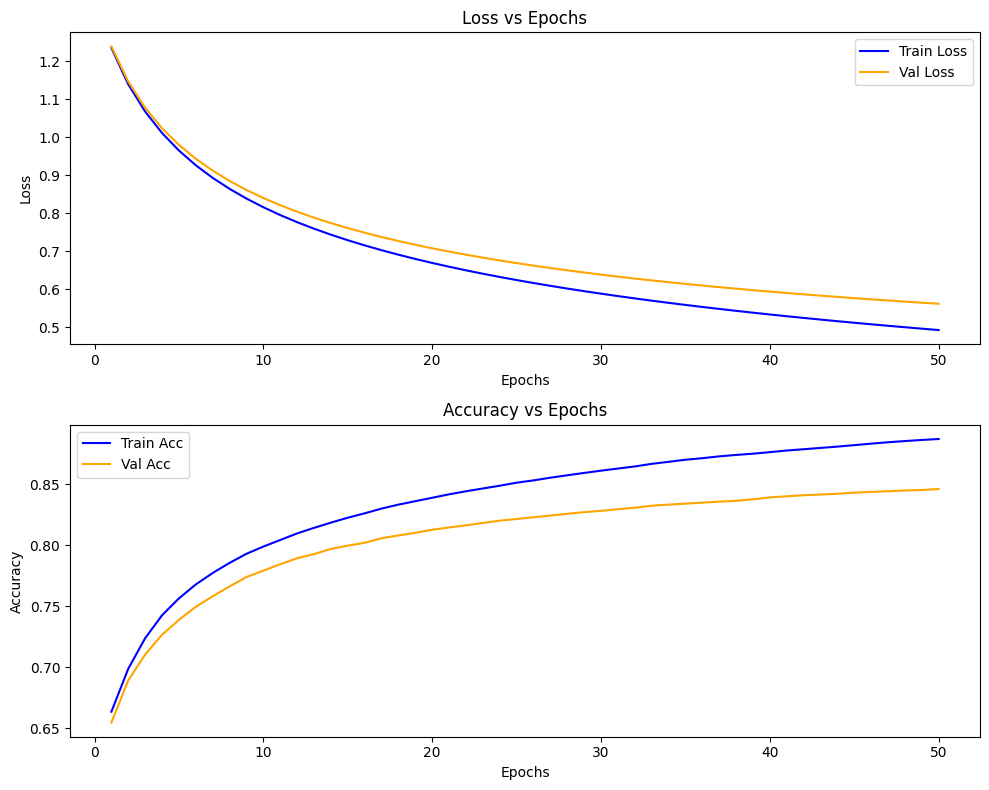

In [22]:
softmax_model = SoftmaxRegression(X_train_split, y_train_split, X_val_split, y_val_split)
softmax_model.train(lr=0.1, epochs=50, batch_size=512)


Scratch Matrix:


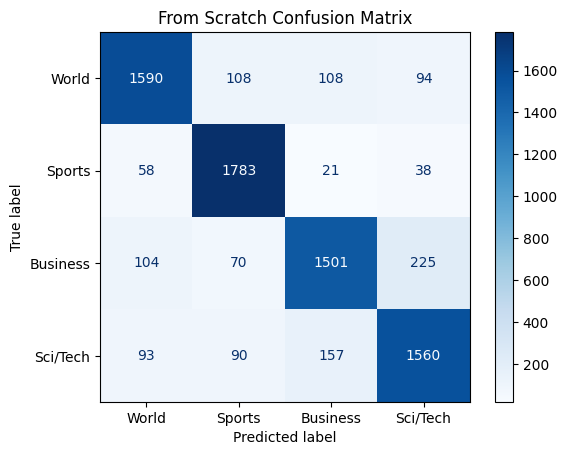

Macro Precision: 0.8462
Macro Recall: 0.8466
Macro F1-Score: 0.8458

Sklearn metrics:


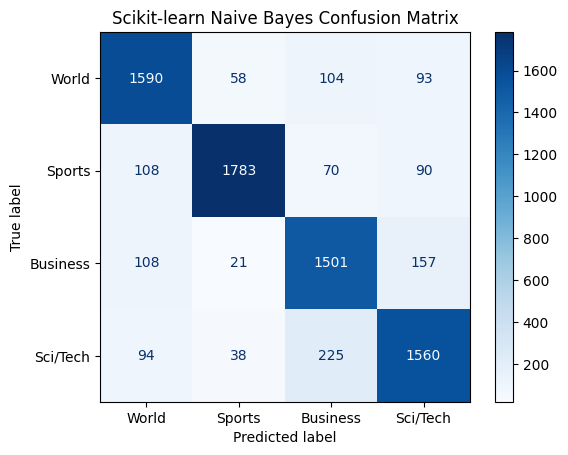

Macro Precision: 0.8466
Macro Recall: 0.8462
Macro F1-Score: 0.8458


In [23]:
test_predictions, y_test_one_hot = softmax_model.test(X_test_bigram, y_test)
test_pred_labels = np.argmax(test_predictions, axis=1)
test_true_labels = y_test - 1 


print("\nScratch Matrix:")
cm, precision, recall, f1 = calculate_metrics(test_true_labels, test_pred_labels, 4)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_idx_to_name.values()))
disp.plot(cmap='Blues')
plt.title("From Scratch Confusion Matrix")
plt.show()
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1-Score: {f1:.4f}")

print("\nSklearn metrics:")
sk_cm = confusion_matrix(test_pred_labels, test_true_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=sk_cm, display_labels=list(label_idx_to_name.values()))
disp.plot(cmap='Blues')
plt.title("Scikit-learn Naive Bayes Confusion Matrix")
plt.show()

sk_precision = precision_score(test_pred_labels, test_true_labels, average='macro')
sk_recall = recall_score(test_pred_labels, test_true_labels, average='macro')
sk_f1 = f1_score(test_pred_labels, test_true_labels, average='macro')

print(f"Macro Precision: {sk_precision:.4f}")
print(f"Macro Recall: {sk_recall:.4f}")
print(f"Macro F1-Score: {sk_f1:.4f}")


## sklearn LogisticRegression

Sklearn SGDClassifier (Logistic Regression) Metrics:


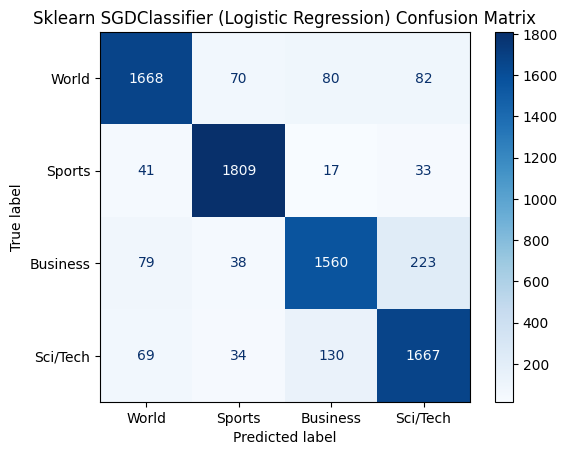

Macro Precision: 0.8825
Macro Recall: 0.8821
Macro F1-Score: 0.8819


In [ ]:
# Train sklearn SGDClassifier with same parameters as scratch model
sk_model = SGDClassifier(loss='log_loss', max_iter=50, eta0=0.1, learning_rate='constant', random_state=42)
sk_model.fit(X_train_split, y_train_split)

# Test sklearn LogisticRegression
sk_test_pred = sk_model.predict(X_test_bigram)

print("Sklearn SGDClassifier (Logistic Regression) Metrics:")
sk_cm = confusion_matrix(y_test - 1, sk_test_pred - 1)
disp = ConfusionMatrixDisplay(confusion_matrix=sk_cm, display_labels=list(label_idx_to_name.values()))
disp.plot(cmap='Blues')
plt.title("Sklearn SGDClassifier (Logistic Regression) Confusion Matrix")
plt.show()

sk_precision = precision_score(y_test - 1, sk_test_pred - 1, average='macro')
sk_recall = recall_score(y_test - 1, sk_test_pred - 1, average='macro')
sk_f1 = f1_score(y_test - 1, sk_test_pred - 1, average='macro')

print(f"Macro Precision: {sk_precision:.4f}")
print(f"Macro Recall: {sk_recall:.4f}")
print(f"Macro F1-Score: {sk_f1:.4f}")

## sklearn SGDClassifier

Sklearn SGDClassifier Metrics:


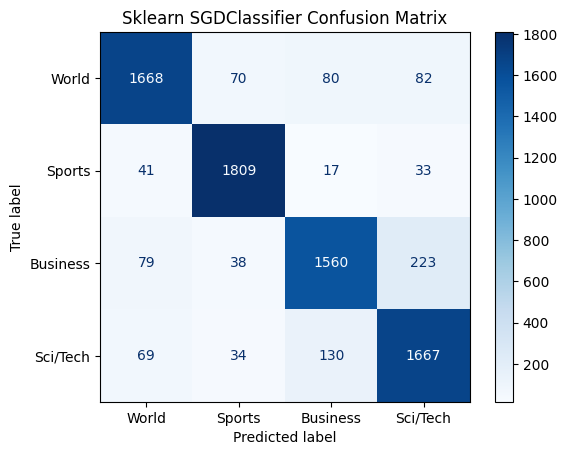

Macro Precision: 0.8825
Macro Recall: 0.8821
Macro F1-Score: 0.8819


In [25]:
# Train sklearn SGDClassifier with same parameters as scratch model
sgd_model = SGDClassifier(loss='log_loss', max_iter=50, eta0=0.1, learning_rate='constant', random_state=42)
sgd_model.fit(X_train_split, y_train_split)

# Test sklearn SGDClassifier
sgd_test_pred = sgd_model.predict(X_test_bigram)

print("Sklearn SGDClassifier Metrics:")
sgd_cm = confusion_matrix(y_test - 1, sgd_test_pred - 1)
disp = ConfusionMatrixDisplay(confusion_matrix=sgd_cm, display_labels=list(label_idx_to_name.values()))
disp.plot(cmap='Blues')
plt.title("Sklearn SGDClassifier Confusion Matrix")
plt.show()

sgd_precision = precision_score(y_test - 1, sgd_test_pred - 1, average='macro')
sgd_recall = recall_score(y_test - 1, sgd_test_pred - 1, average='macro')
sgd_f1 = f1_score(y_test - 1, sgd_test_pred - 1, average='macro')

print(f"Macro Precision: {sgd_precision:.4f}")
print(f"Macro Recall: {sgd_recall:.4f}")
print(f"Macro F1-Score: {sgd_f1:.4f}")

## Model Comparison

In [27]:
# Reuse metrics already computed above
scratch_acc = np.mean(test_true_labels == test_pred_labels)
scratch_per_class = np.diag(cm) / cm.sum(axis=1)

comparison_data = {
    'Model': ['Scratch Softmax', 'Sklearn LogisticRegression', 'Sklearn SGDClassifier'],
    'Accuracy': [
        scratch_acc,
        np.mean((y_test - 1) == (sk_test_pred - 1)),
        np.mean((y_test - 1) == (sgd_test_pred - 1))
    ],
    'Precision': [precision, sk_precision, sgd_precision],
    'Recall': [recall, sk_recall, sgd_recall],
    'F1-Score': [f1, sk_f1, sgd_f1]
}

comparison_df = pd.DataFrame(comparison_data)

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

print("\nPer-Class Accuracy Comparison:")
print("\nScratch Model Per-Class Accuracies:")
for label, acc in zip(label_idx_to_name.values(), scratch_per_class):
    print(f"  {label}: {acc:.4f}")

MODEL PERFORMANCE COMPARISON
                     Model  Accuracy  Precision   Recall  F1-Score
           Scratch Softmax  0.846579   0.846212 0.846579  0.845824
Sklearn LogisticRegression  0.882105   0.882458 0.882105  0.881858
     Sklearn SGDClassifier  0.882105   0.882458 0.882105  0.881858

Per-Class Accuracy Comparison:

Scratch Model Per-Class Accuracies:
  World: 0.8368
  Sports: 0.9384
  Business: 0.7900
  Sci/Tech: 0.8211
